In [1]:
import numpy as np
import tensorflow as tf 
from tensorflow import keras
import torch
import os

In [2]:
DATASET_ROOT = r"C:\Users\14362\Desktop\DL\Assignment\Group Project\DL_RIR_AousticAnalysis\dataset"
AUDIO_DIR = os.path.join(DATASET_ROOT, "audio")
LABEL_DIR = os.path.join(DATASET_ROOT, "labels")

TRAIN_CSV = os.path.join(LABEL_DIR, "train_labels_classification.csv")
VAL_CSV = os.path.join(LABEL_DIR, "validation_labels_classification.csv")
TEST_CSV = os.path.join(LABEL_DIR, "test_labels_classification.csv")


In [3]:
from bl_data_load import load_dataset

In [4]:
train_X, train_Y = load_dataset(TRAIN_CSV, save_prefix="train")    
val_X, val_Y = load_dataset(VAL_CSV, save_prefix="val")    
test_X, test_Y = load_dataset(TEST_CSV, save_prefix="test")

# freq_bins = logmels.shape[1]

# front_cnn = FrontCNN(freq_bins=freq_bins, input_dim=128)

# train_loader = make_pytorch_loader(train_logmels, train_labels, batch_size=16)
# val_loader = make_pytorch_loader(val_logmels, val_labels, batch_size=16, shuffle=None)

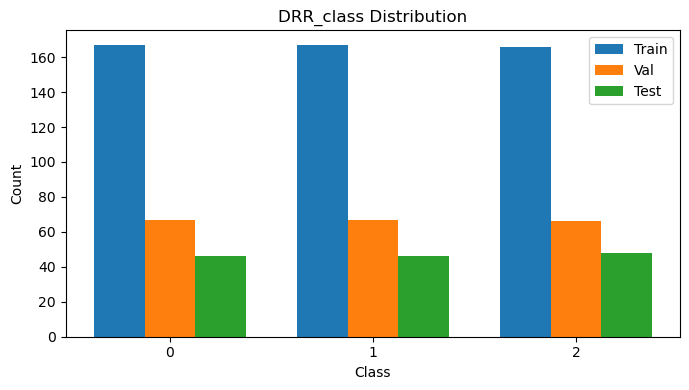

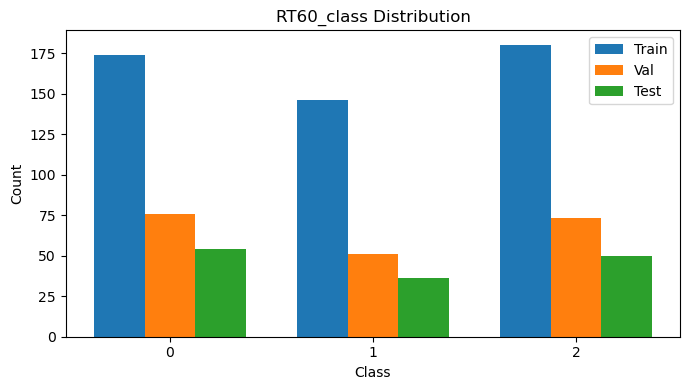

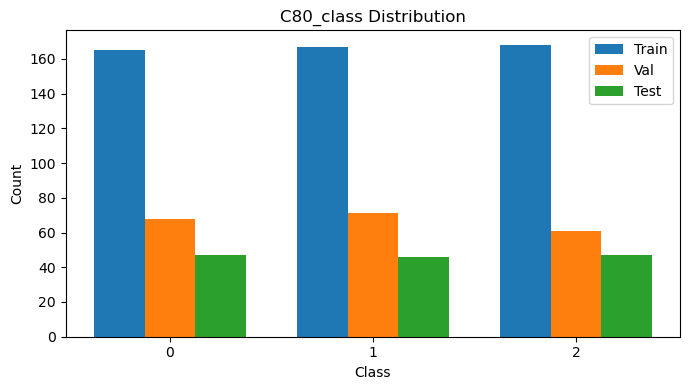

In [5]:
import numpy as np
import matplotlib.pyplot as plt

label_names = ["DRR_class", "RT60_class", "C80_class"]
datasets = {
    "Train": train_Y,
    "Val": val_Y,
    "Test": test_Y,
}

for i, name in enumerate(label_names):
    # 收集所有可能的类别（保证对齐）
    all_classes = sorted(
        set(train_Y[:, i]) | set(val_Y[:, i]) | set(test_Y[:, i])
    )

    def count_per_class(Y, classes):
        return [np.sum(Y[:, i] == c) for c in classes]

    train_counts = count_per_class(train_Y, all_classes)
    val_counts   = count_per_class(val_Y, all_classes)
    test_counts  = count_per_class(test_Y, all_classes)

    x = np.arange(len(all_classes))
    width = 0.25

    plt.figure(figsize=(7, 4))

    plt.bar(x - width, train_counts, width, label="Train")
    plt.bar(x,         val_counts,   width, label="Val")
    plt.bar(x + width, test_counts,  width, label="Test")

    plt.xticks(x, all_classes)
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.title(f"{name} Distribution")
    plt.legend()

    plt.tight_layout()
    plt.show()